<a href="https://colab.research.google.com/github/HamzaEric/Pet_Breed_Classification/blob/main/Notebooks/CNN_Foundation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms
import numpy as np
from torch.utils.data import Subset
import os
from PIL import Image
import torch.nn.functional as F
import shutil
from pathlib import Path

100%|██████████| 792M/792M [00:23<00:00, 33.6MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 15.5MB/s]


Number of images: 3680
Number of classes: 37
Example classes: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']


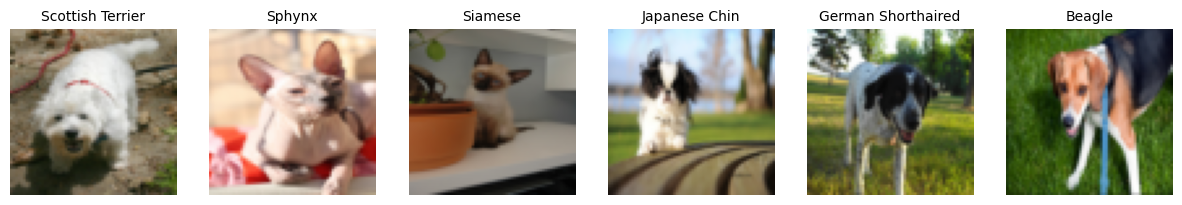

In [3]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Load the Oxford-IIIT Pets dataset
train_dataset = datasets.OxfordIIITPet(
    root="./data/",
    split="trainval",
    target_types="category",
    download=True,
    transform=transform
)

print(f"Number of images: {len(train_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Example classes: {train_dataset.classes[:5]}")

def show_samples(dataset, n=6):
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for i in range(n):
        idx = np.random.randint(len(dataset))
        img, label = dataset[idx]
        axes[i].imshow(img.permute(1, 2, 0))  # Convert CHW → HWC
        axes[i].set_title(dataset.classes[label], fontsize=10)
        axes[i].axis("off")
    plt.show()

show_samples(train_dataset)

# Convolution
a convolution is a mathematical operation that slides a small matrix of numbers (called a kernel or filter) over an image to detect specific visual features like edges, textures, or shapes.

Instead of looking at the entire image at once, a convolution analyzes small, localized patches of pixels to understand how they relate to their immediate neighbors.

**How Does It Work?**

A convolution layer slides a **filter (kernel)** across the image. At each position, it performs **element-wise multiplication** followed by a **sum** to produce a single output value. Repeating this across the image forms the **feature map**.

Mathematically, a 2D convolution is:

$$
S(i,j) = \sum_m \sum_n I(i+m, j+n) \cdot K(m,n)
$$

where:
- $ I $= input image  
- $ K $ = convolution filter  
- $ S $ = resulting feature map  


**Key Hyperparameters**

1. **Filter Size (Kernel Size)**  
   - Typically $3 \times 3$ or $5 \times 5$.  
   - Larger filters capture bigger patterns but are more computationally expensive.

2. **Stride**  
   - How far the filter moves per step.  
   - Stride = 1: maximum overlap. Stride = 2: skips pixels (downsampling).

3. **Padding**  
   - Adds zeros around the border to preserve image size after convolution.  
   - Without padding, feature maps shrink after each layer.


**Why This Matters**

- **Parameter Efficiency:** A $3 \times 3$ filter uses 9 parameters but scans the whole image.  
- **Translation Invariance:** A detected edge is recognized regardless of its location.  
- **Hierarchical Learning:** Early layers detect edges → middle layers detect textures → deeper layers recognize objects.


**Example: Edge Detection**

A simple horizontal edge filter:

$$
\begin{bmatrix}
-1 & -1 & -1 \\
0 & 0 & 0 \\
1 & 1 & 1
\end{bmatrix}
$$

This highlights **horizontal changes** in intensity — transitions from dark to light.

**What’s Next**

In the next section, we’ll **implement convolution manually with NumPy**. This will give us an **intuitive feel** for how filters slide across an image and produce feature maps — before using PyTorch’s built-in functions.

---

### **4. Manual Convolution Implementation (NumPy)**

**Why Implement Convolution Manually?**

Before relying on PyTorch’s `nn.Conv2d`, it’s vital to understand what’s happening “under the hood.” By manually coding convolution with **NumPy**, we will:

- Demystify how filters slide across an image.
- Visualize how edge detection or blurring emerges from simple arithmetic.
- Build intuition for **kernel size**, **stride**, and **padding**.


**Step 1: Create a Toy Image**

We will use a small **grayscale image** (e.g., $6 \times 6$ pixels) so calculations remain tangible.  
Each value represents pixel intensity ($0 =$ black, $255 =$ white).

For example:

$$
\begin{bmatrix}
10 & 10 & 10 & 0 & 0 & 0 \\
10 & 10 & 10 & 0 & 0 & 0 \\
10 & 10 & 10 & 0 & 0 & 0 \\
0  & 0  & 0  & 20 & 20 & 20 \\
0  & 0  & 0  & 20 & 20 & 20 \\
0  & 0  & 0  & 20 & 20 & 20
\end{bmatrix}
$$

This toy image contains **two contrasting blocks** (dark vs. bright) — perfect for testing edge detection.

**Step 2: Define a Filter (Kernel)**

A **filter** is a small matrix, usually $3 \times 3$ or $5 \times 5$.  
For horizontal edge detection, we can use:

$$
\begin{bmatrix}
-1 & -1 & -1 \\
0  &  0 &  0 \\
1  &  1 &  1
\end{bmatrix}
$$

This highlights **horizontal changes** in pixel values.

**Step 3: Perform Convolution**

**Process:**

1. Place the filter at the **top-left** corner of the image.
2. Multiply overlapping values and **sum them up**.
3. Move the filter by **one pixel** (stride = 1) and repeat.
4. Continue until the filter slides across the entire image.


**Expected Outcome**

- The output (feature map) will highlight **edges** where pixel intensity changes rapidly.  
- For our toy image, the boundary between the top-left block (value $10$) and bottom-right block (value $20$) should appear as a **strong response**.

In the next cell, we will code this step-by-step, starting with a simple **2D convolution for grayscale images**.


Resulting Feature Map (Matrix):
[[  0.   0.   0.   0.]
 [-30.   0.  30.  60.]
 [-30.   0.  30.  60.]
 [  0.   0.   0.   0.]]


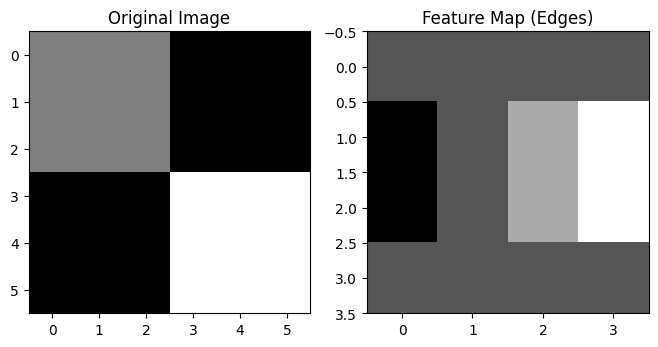

In [5]:
image = np.array([
    [10, 10, 10, 0, 0, 0],
    [10, 10, 10, 0, 0, 0],
    [10, 10, 10, 0, 0, 0],
    [0, 0, 0, 20, 20, 20],
    [0, 0, 0, 20, 20, 20],
    [0, 0, 0, 20, 20, 20]
])

kernel = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
])

def convolve2d(image, kernel, stride=1, padding=0):

    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)

    kernel_height, kernel_width = kernel.shape
    img_height, img_width = image.shape

    out_height = (img_height - kernel_height) // stride + 1
    out_width = (img_width - kernel_width) // stride + 1

    output = np.zeros((out_height, out_width))

    for y in range(0, img_height - kernel_height + 1, stride):
        for x in range(0, img_width - kernel_width + 1, stride):
            region = image[y:y+kernel_height, x:x+kernel_width]
            output[y//stride, x//stride] = np.sum(region * kernel)

    return output

# Apply convolution
feature_map = convolve2d(image, kernel)

# Print resulting matrix for clarity
print("Resulting Feature Map (Matrix):")
print(feature_map)

# Visualize
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(image, cmap='gray')
axs[0].set_title("Original Image")
axs[1].imshow(feature_map, cmap='gray')
axs[1].set_title("Feature Map (Edges)")
plt.show()


# Horizontal Edge Detection

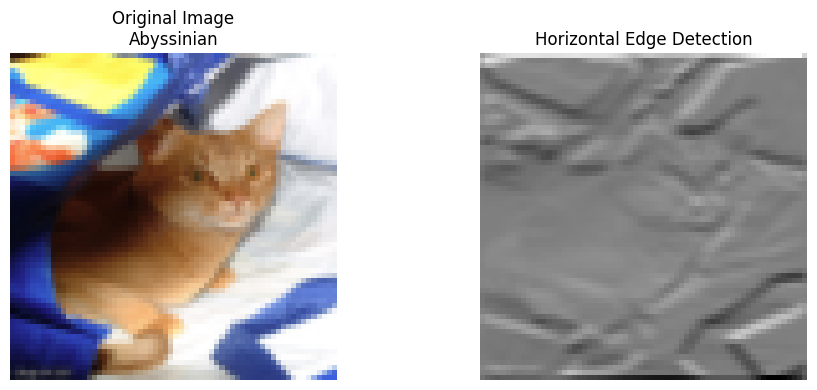

In [6]:
img, label = train_dataset[0]  # CHW format, [0,1] range
img_batch = img.unsqueeze(0)   # Add batch dim: (1,3,H,W)

# Horizontal edge detection kernel (same for R,G,B)
horizontal_kernel = torch.tensor(
    [[[-1, -1, -1],
      [ 0,  0,  0],
      [ 1,  1,  1]],  # Red

     [[-1, -1, -1],
      [ 0,  0,  0],
      [ 1,  1,  1]],  # Green

     [[-1, -1, -1],
      [ 0,  0,  0],
      [ 1,  1,  1]]]  # Blue
).unsqueeze(0).float()  # Shape: (1,3,3,3)

# Apply convolution
horizontal_feature_map = F.conv2d(img_batch, horizontal_kernel, stride=1, padding=1)

# Show original and feature map side by side
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(img.permute(1, 2, 0))
axs[0].set_title(f"Original Image\n{train_dataset.classes[label]}")
axs[0].axis("off")

axs[1].imshow(horizontal_feature_map[0, 0].detach().numpy(), cmap="gray")
axs[1].set_title("Horizontal Edge Detection")
axs[1].axis("off")

plt.tight_layout()
plt.show()

# Vertical Edge Detection

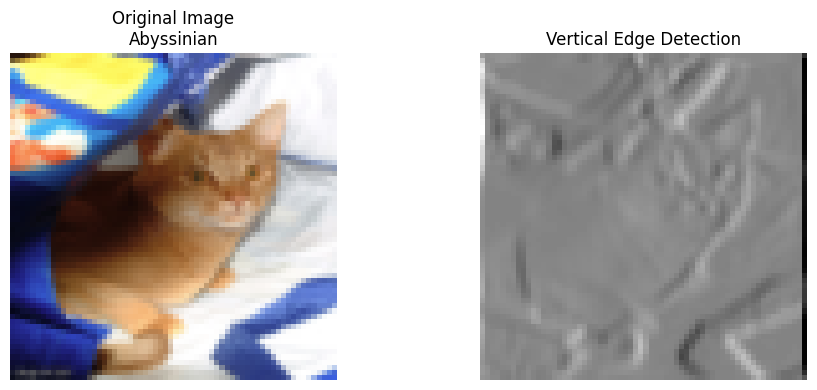

In [8]:
# Vertical edge detection kernel (same for R,G,B)
vertical_kernel = torch.tensor(
    [[[ -1,  0,  1],
      [ -1,  0,  1],
      [ -1,  0,  1]],  # Red

     [[ -1,  0,  1],
      [ -1,  0,  1],
      [ -1,  0,  1]],  # Green

     [[ -1,  0,  1],
      [ -1,  0,  1],
      [ -1,  0,  1]]]  # Blue
).unsqueeze(0).float()  # Shape: (1,3,3,3)

# Apply convolution
vertical_feature_map = F.conv2d(img_batch, vertical_kernel, stride=1, padding=1)

# Show original and feature map side by side
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(img.permute(1, 2, 0))
axs[0].set_title(f"Original Image\n{train_dataset.classes[label]}")
axs[0].axis("off")

axs[1].imshow(vertical_feature_map[0, 0].detach().numpy(), cmap="gray")
axs[1].set_title("Vertical Edge Detection")
axs[1].axis("off")

plt.tight_layout()
plt.show()

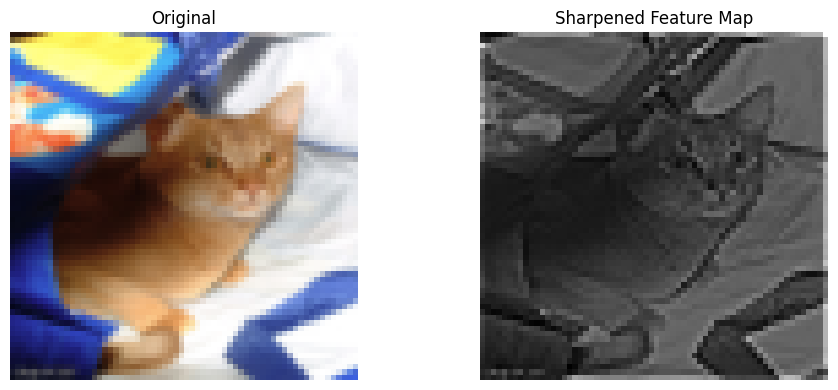

In [9]:
CT_sharpen_kernel = torch.tensor(
    [[[ 0, -1,  0],
      [-1,  5, -1],
      [ 0, -1,  0]],

     [[ 0, -1,  0],
      [-1,  5, -1],
      [ 0, -1,  0]],

     [[ 0, -1,  0],
      [-1,  5, -1],
      [ 0, -1,  0]]]
).unsqueeze(0).float()

# Prepare input image (batch, channel, H, W)
# (Assuming `img` is already loaded from the dataset in (C, H, W) format)
CT_img_batch = img.unsqueeze(0)

# Apply convolution
CT_sharpen_map = F.conv2d(CT_img_batch, CT_sharpen_kernel, stride=1, padding=1)

# Visualize
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(img.permute(1, 2, 0))
axs[0].set_title("Original")
axs[0].axis("off")

# Extract the single feature map from the batch for plotting
axs[1].imshow(CT_sharpen_map[0, 0].detach().numpy(), cmap="gray")
axs[1].set_title("Sharpened Feature Map")
axs[1].axis("off")

plt.tight_layout()
plt.show()

### **6. Pooling Layers**

**Why Pooling?**

When convolutional layers generate feature maps, they preserve most of the original spatial details — every small change in the input image is reflected in these maps. While this is useful for capturing fine details, it quickly becomes inefficient as networks get deeper: feature maps remain large, computations become heavier, and the model risks focusing too much on tiny pixel-level variations.

Pooling layers solve this by **condensing the information** in a feature map. Instead of looking at every pixel, pooling looks at small regions (like `2×2` blocks) and summarizes them — for example, by taking the **maximum value** (max pooling) or the **average value** (average pooling). This achieves two things at once:  
1. It **reduces the size** of the data flowing through the network, making computations faster and reducing the number of parameters in later layers.  
2. It makes the network more **robust to small shifts or distortions** in the input image — if an object moves slightly, the strongest features (like edges or textures) still appear in the pooled map.

In simpler terms, pooling acts like a way of **zooming out**: we keep the most important patterns and ignore small irrelevant variations, helping the network focus on **what** is present rather than **exactly where** it is.


**Types of Pooling**

1. **Max Pooling**

Selects the **maximum value** in each window:

$$
\text{MaxPool}(2\times 2) \to \text{take max of each 2x2 block}
$$

2. **Average Pooling**

Takes the **average value** in each window:

$$
\text{AvgPool}(2\times 2) \to \text{average values in each 2x2 block}
$$


**Visual Intuition**

Example: $4 \times 4$ feature map pooled with $2 \times 2$ max pooling.

**Original Feature Map**


$$
\begin{bmatrix}
1 & 2 & 5 & 6 \\
3 & 4 & 7 & 8 \\
9 & 10 & 13 & 14 \\
11 & 12 & 15 & 16
\end{bmatrix}
$$

**After $2 \times 2$ Max Pooling**

$$
\begin{bmatrix}
4 & 8 \\
12 & 16
\end{bmatrix}
$$

Pooling reduces dimensions by a factor of 2 (from $4\times4$ to $2\times2$) while keeping the **strongest activations**.



**What We’ll Do**

1. Toy NumPy example: Max vs. Average pooling on a small matrix.
2. PyTorch example: Apply pooling to an **edge-detected feature map** from Section 5.
3. Observe **downsampling** and discuss **translation invariance**.


In [10]:
feature_map = np.array([
    [1, 2, 5, 6],
    [3, 4, 7, 8],
    [9, 10, 13, 14],
    [11, 12, 15, 16]
])

def pool2d(matrix, size=2, mode="max"):
    H, W = matrix.shape
    pooled = []
    for i in range(0, H, size):
        row = []
        for j in range(0, W, size):
            window = matrix[i:i+size, j:j+size]
            if mode == "max":
                row.append(np.max(window))
            else:
                row.append(np.mean(window))
        pooled.append(row)
    return np.array(pooled)

max_pooled = pool2d(feature_map, size=2, mode="max")
avg_pooled = pool2d(feature_map, size=2, mode="avg")

print("Original Feature Map:\n", feature_map)
print("\nMax Pooled (2x2):\n", max_pooled)
print("\nAverage Pooled (2x2):\n", avg_pooled)

Original Feature Map:
 [[ 1  2  5  6]
 [ 3  4  7  8]
 [ 9 10 13 14]
 [11 12 15 16]]

Max Pooled (2x2):
 [[ 4  8]
 [12 16]]

Average Pooled (2x2):
 [[ 2.5  6.5]
 [10.5 14.5]]


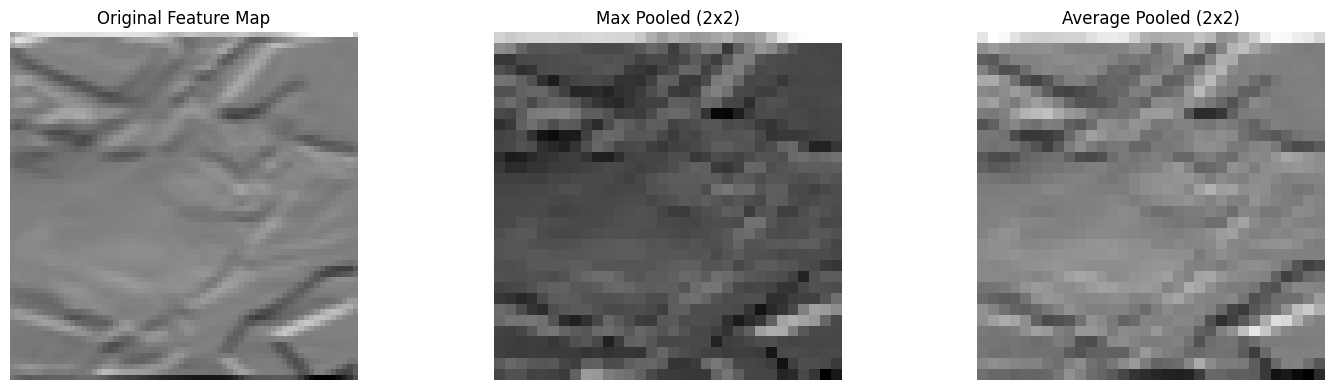

In [11]:
max_pooled_map = F.max_pool2d(horizontal_feature_map, kernel_size=2, stride=2)


avg_pooled_map = F.avg_pool2d(horizontal_feature_map, kernel_size=2, stride=2)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].imshow(horizontal_feature_map[0, 0].detach().numpy(), cmap="gray")
axs[0].set_title("Original Feature Map")
axs[0].axis("off")

axs[1].imshow(max_pooled_map[0, 0].detach().numpy(), cmap="gray")
axs[1].set_title("Max Pooled (2x2)")
axs[1].axis("off")

axs[2].imshow(avg_pooled_map[0, 0].detach().numpy(), cmap="gray")
axs[2].set_title("Average Pooled (2x2)")
axs[2].axis("off")

plt.tight_layout()
plt.show()

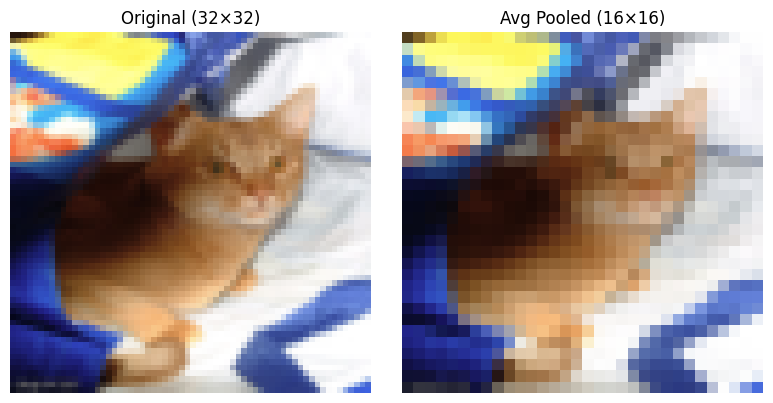

In [13]:
CT_sample_img, _ = train_dataset[0]  # Shape: (3, 32, 32)
CT_sample_batch = CT_sample_img.unsqueeze(0)

CT_avg_pooled = F.avg_pool2d(CT_sample_batch, kernel_size=2, stride=2)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(CT_sample_img.permute(1, 2, 0))
axs[0].set_title("Original (32×32)")
axs[0].axis("off")


axs[1].imshow(CT_avg_pooled[0].permute(1, 2, 0).detach().numpy())
axs[1].set_title("Avg Pooled (16×16)")
axs[1].axis("off")

plt.tight_layout()
plt.show()